<a href="https://colab.research.google.com/github/athi-raj/Heart-Disease-Predictor/blob/main/Heart_Disease_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import & load

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow: {tf.__version__} | GPU: {tf.config.list_physical_devices('GPU') or 'None'}")

DATA_PATH = '/content/drive/MyDrive/Heart-Disease-Predictor/heart_disease_uci.csv'
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape} | Columns: {df.columns.tolist()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0 | GPU: None
Shape: (920, 16) | Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Data Cleaning & EDA

Missing values:
 Series([], )


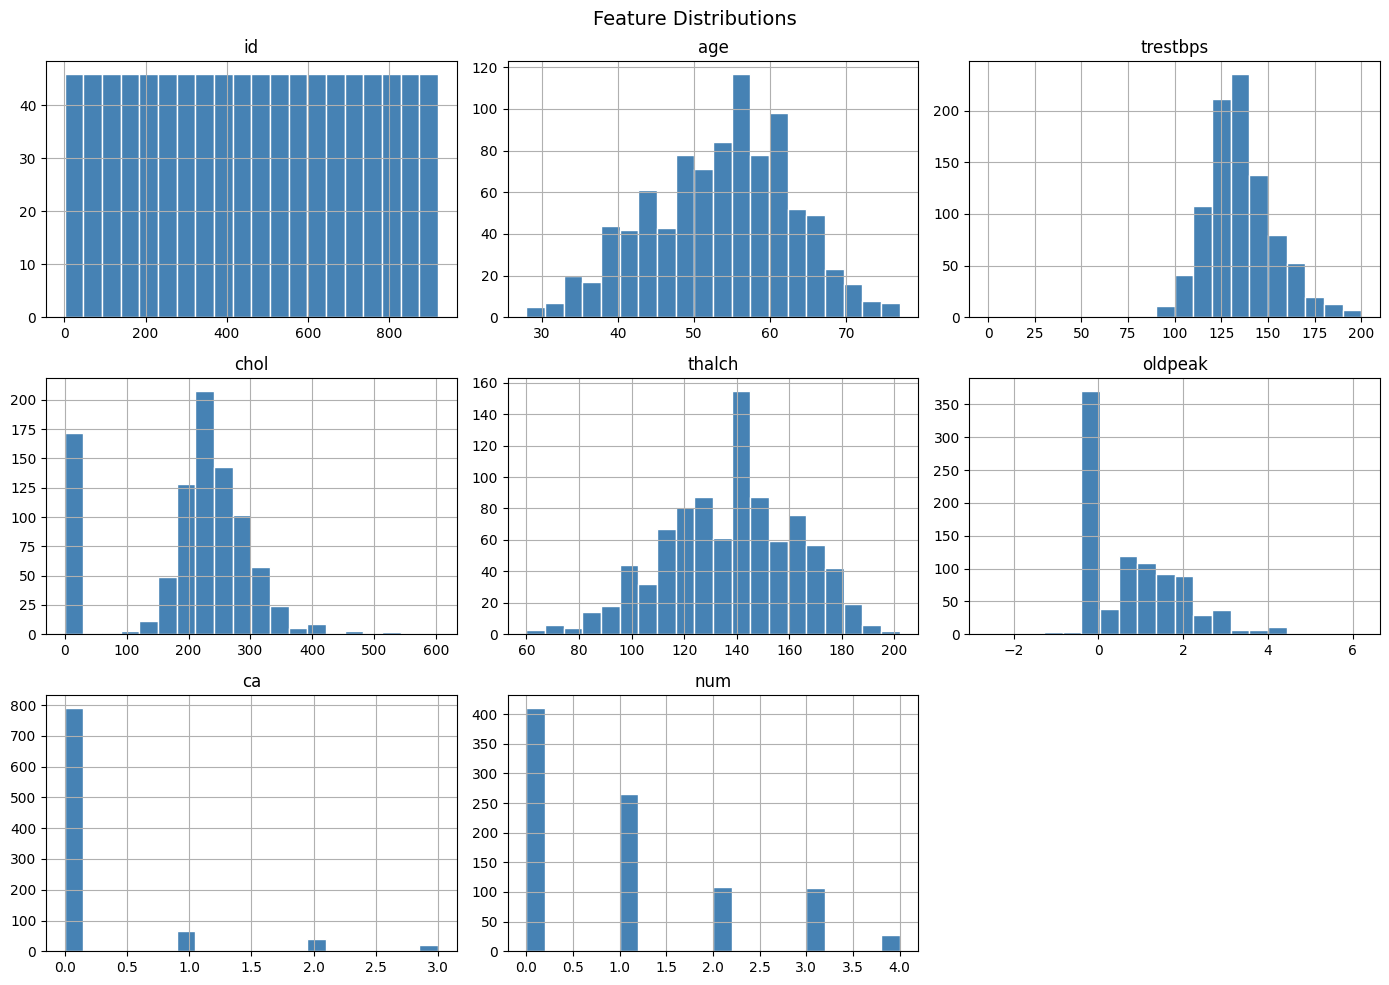

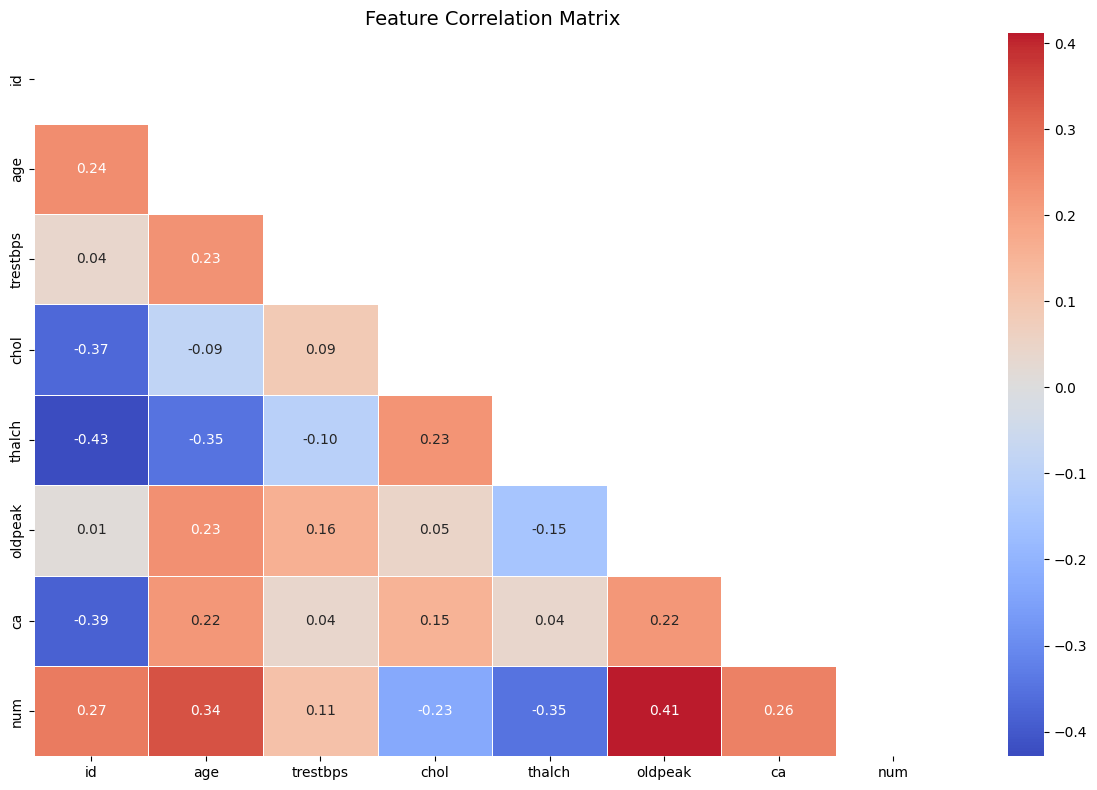

In [6]:
# CELL 2 — EDA & Preprocessing

numeric_cols = df.select_dtypes(include='number').columns
cat_cols     = df.select_dtypes(include='object').columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[cat_cols]     = df[cat_cols].fillna('Unknown')

print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0].to_string() or "None")

df[numeric_cols].hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df[numeric_cols].corr(), dtype=bool))
sns.heatmap(
    df[numeric_cols].corr(),
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

Feature Engineering & Train-Test Split

In [7]:
# CELL 3 — Feature Engineering & Splitting

y = (df['num'] > 0).astype(int)
X = pd.get_dummies(df.drop('num', axis=1))

feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, '/content/drive/MyDrive/Heart-Disease-Predictor/scaler.pkl')

print(f"Train : {len(X_train)} | Test : {len(X_test)} | Features : {len(feature_columns)}")
print(f"Positive rate — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Train : 736 | Test : 184 | Features : 35
Positive rate — Train: 55.30% | Test: 55.43%


TensorFlow Model Training

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7415 - auc: 0.8183 - loss: 0.5266 - val_accuracy: 0.8378 - val_auc: 0.8953 - val_loss: 0.5558 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8316 - auc: 0.9121 - loss: 0.3768 - val_accuracy: 0.8176 - val_auc: 0.9032 - val_loss: 0.5019 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8469 - auc: 0.9313 - loss: 0.3372 - val_accuracy: 0.8378 - val_auc: 0.9077 - val_loss: 0.4678 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8793 - auc: 0.9500 - loss: 0.2967 - val_accuracy: 0.8311 - val_auc: 0.9062 - val_loss: 0.4384 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9065 - auc: 0.9593 - loss: 0.2645 - val_accuracy: 0.8446 - val_auc: 0.9021 - val_loss: 0.4161 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9218 - auc: 0.9734 

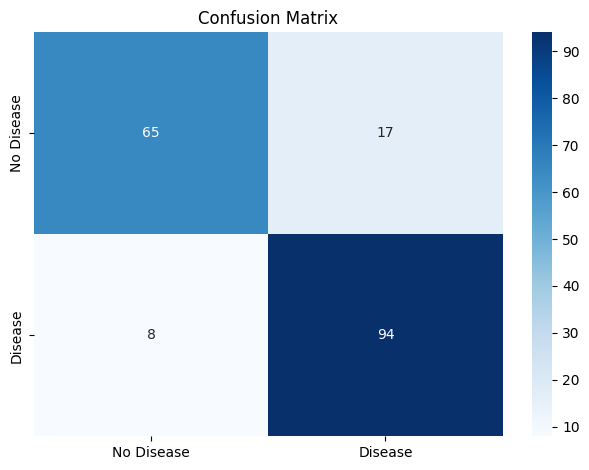

In [8]:
# CELL 4 — Model Training & Evaluation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),

    Dense(64, activation='relu'),
    BatchNormalization(),

    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks = [
    EarlyStopping(monitor='val_auc', patience=15, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1)
]

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)[:2]
print(f"Accuracy: {round(accuracy*100, 2)}%")

y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

Save Model & Single Patient Prediction

In [9]:
# CELL 5 — Save Model & Single Patient Prediction

model.save('/content/drive/MyDrive/Heart-Disease-Predictor/heart_disease_model.keras')
joblib.dump(scaler,          '/content/drive/MyDrive/Heart-Disease-Predictor/heart_scaler.pkl')
joblib.dump(feature_columns, '/content/drive/MyDrive/Heart-Disease-Predictor/heart_features.pkl')
print("Model, scaler and features saved.")

# Sample patient prediction
sample = X.iloc[[0]].copy()
sample['age']      = 55
sample['trestbps'] = 140
sample['chol']     = 240
sample['thalch']   = 150
sample['oldpeak']  = 1.5

sample_scaled = scaler.transform(sample)
prediction    = model.predict(sample_scaled, verbose=0)
probability   = prediction[0][0]

print(f"\nPrediction probability : {probability:.4f}")
print(f"Result : {'Heart Disease Detected' if probability > 0.5 else 'No Heart Disease'}")

Model, scaler and features saved.

Prediction probability : 0.4386
Result : No Heart Disease


In [10]:
# CELL 6 — GUI Prediction (ipywidgets)

import ipywidgets as widgets
from IPython.display import display, HTML

display(HTML("""
<style>
  @import url('https://fonts.googleapis.com/css2?family=DM+Serif+Display&family=DM+Mono:wght@400;500&display=swap');
  .widget-label { font-family: 'DM Mono', monospace !important; font-size: 11px !important; color: #8a9bb0 !important; text-transform: uppercase; letter-spacing: 1px; }
  .card { background: #0d1117; border: 1px solid #21262d; border-radius: 12px; padding: 28px 32px; max-width: 720px; margin: 16px auto; }
  .title { font-family: 'DM Serif Display', serif; font-size: 26px; color: #e6edf3; margin-bottom: 4px; }
  .subtitle { font-family: 'DM Mono', monospace; font-size: 12px; color: #8a9bb0; margin-bottom: 24px; letter-spacing: 1px; }
  .result-box { border-radius: 10px; padding: 20px 24px; margin-top: 20px; font-family: 'DM Mono', monospace; }
  .result-positive { background: #2d1b1b; border: 1px solid #f85149; color: #f85149; }
  .result-negative { background: #1b2d1e; border: 1px solid #3fb950; color: #3fb950; }
  .result-title { font-size: 16px; font-weight: 500; margin-bottom: 6px; }
  .result-prob { font-size: 12px; opacity: 0.8; }
  .widget-button button { background: #238636 !important; color: #fff !important; border: none !important; border-radius: 8px !important; font-family: 'DM Mono', monospace !important; font-size: 13px !important; padding: 8px 24px !important; cursor: pointer !important; transition: opacity 0.2s !important; }
  .widget-button button:hover { opacity: 0.85 !important; }
</style>
<div class="card">
  <div class="title">Heart Disease Predictor</div>
  <div class="subtitle">CLINICAL RISK ASSESSMENT · ML MODEL</div>
</div>
"""))

# ── Inputs ──────────────────────────────────
style  = {'description_width': '160px'}
layout = widgets.Layout(width='340px')

age      = widgets.IntSlider(value=50, min=1, max=100, description='Age', style=style, layout=layout)
sex      = widgets.Dropdown(options=['Male','Female'], description='Sex', style=style, layout=layout)
dataset  = widgets.Dropdown(options=['Cleveland','Hungary','Switzerland','VA Long Beach'], description='Dataset', style=style, layout=layout)
cp       = widgets.Dropdown(options=['typical angina','atypical angina','non-anginal','asymptomatic'], description='Chest Pain', style=style, layout=layout)
trestbps = widgets.IntSlider(value=120, min=80, max=220, description='Resting BP (mmHg)', style=style, layout=layout)
chol     = widgets.IntSlider(value=200, min=100, max=600, description='Cholesterol', style=style, layout=layout)
fbs      = widgets.Dropdown(options=['True','False'], description='Fasting BS > 120', style=style, layout=layout)
restecg  = widgets.Dropdown(options=['normal','st-t abnormality','lv hypertrophy'], description='Rest ECG', style=style, layout=layout)
thalch   = widgets.IntSlider(value=150, min=60, max=220, description='Max Heart Rate', style=style, layout=layout)
exang    = widgets.Dropdown(options=['True','False'], description='Exercise Angina', style=style, layout=layout)
oldpeak  = widgets.FloatSlider(value=1.0, min=0.0, max=7.0, step=0.1, description='Oldpeak', style=style, layout=layout)
slope    = widgets.Dropdown(options=['upsloping','flat','downsloping'], description='Slope', style=style, layout=layout)
ca       = widgets.FloatSlider(value=0.0, min=0.0, max=4.0, step=1.0, description='Major Vessels (ca)', style=style, layout=layout)
thal     = widgets.Dropdown(options=['normal','fixed defect','reversable defect'], description='Thal', style=style, layout=layout)

btn    = widgets.Button(description='Run Prediction', button_style='')
btn.add_class('widget-button')
output = widgets.Output()

col1 = widgets.VBox([age, sex, dataset, cp, trestbps, chol, fbs])
col2 = widgets.VBox([restecg, thalch, exang, oldpeak, slope, ca, thal])
grid = widgets.HBox([col1, col2], layout=widgets.Layout(gap='32px'))

display(widgets.VBox([grid, btn, output], layout=widgets.Layout(max_width='760px', margin='0 auto')))

# ── Prediction logic ────────────────────────
def predict(b):
    output.clear_output()
    patient = pd.DataFrame({
        'id':[999], 'age':[age.value], 'sex':[sex.value],
        'dataset':[dataset.value], 'cp':[cp.value],
        'trestbps':[float(trestbps.value)], 'chol':[float(chol.value)],
        'fbs':[fbs.value], 'restecg':[restecg.value],
        'thalch':[float(thalch.value)], 'exang':[exang.value],
        'oldpeak':[float(oldpeak.value)], 'slope':[slope.value],
        'ca':[float(ca.value)], 'thal':[thal.value]
    })

    patient_encoded = pd.get_dummies(patient)
    patient_encoded = patient_encoded.reindex(columns=feature_columns, fill_value=0)
    patient_scaled  = scaler.transform(patient_encoded)
    probability     = model.predict(patient_scaled, verbose=0)[0][0]

    result_class = 'result-positive' if probability > 0.5 else 'result-negative'
    result_text  = '⚠ Heart Disease Detected' if probability > 0.5 else '✓ No Heart Disease'
    conf         = probability * 100 if probability > 0.5 else (1 - probability) * 100

    with output:
        display(HTML(f"""
        <div class="result-box {result_class}">
            <div class="result-title">{result_text}</div>
            <div class="result-prob">Confidence: {conf:.2f}% · Raw probability: {probability:.4f}</div>
        </div>
        """))

btn.on_click(predict)